# music2speech: results aggregation

Aggregates probe metrics across pretraining conditions and seeds. Reads
`best_metrics.json` files under `runs/` (default seed) and
`runs/seed{N}/` (extra seeds), computes per-(condition, task) means and
stds, and produces a comparison figure.

Re-running the cells will pick up newly-completed runs automatically.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
RUNS = Path("/workspace/i_tatsuro/projects/music2speech/runs")
FIG_DIR = Path("/workspace/i_tatsuro/projects/music2speech/notebooks/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# (seed_label, base directory containing <cond>/probe_<task>/best_metrics.json)
SEED_DIRS = {
    "42": RUNS,           # default split-seed; the original runs are flat under runs/
    "43": RUNS / "seed43",
    "44": RUNS / "seed44",
}

# Display order. random_init is the no-pretrain baseline; esc50 is the
# non-music control. The four POP909 conditions are intact (A) +
# pitch_strip (B) + rhythm_strip (C) + both_strip (D).
CONDS = ["intact", "pitch_strip", "rhythm_strip", "both_strip", "esc50", "random_init"]

# Pretty labels for tables / plots.
COND_LABEL = {
    "intact":       "A: intact",
    "pitch_strip":  "B: pitch-stripped",
    "rhythm_strip": "C: rhythm-stripped",
    "both_strip":   "D: both-stripped",
    "esc50":        "E: ESC-50 (non-music)",
    "random_init":  "F: random init",
}

# Per-task metric metadata.
TASKS = {
    # Frame-level probes (LibriSpeech).
    "phone":    {"dir": "probe_phone",    "metric": "eval_frame_acc",  "label": "Phoneme acc (↑)",      "better": "high"},
    "boundary": {"dir": "probe_boundary", "metric": "eval_f1",         "label": "Boundary F1 (↑)",     "better": "high"},
    "f0":       {"dir": "probe_f0",       "metric": "eval_rmse_cents", "label": "F0 RMSE [cents] (↓)", "better": "low"},
    # Utterance-level probes (Speech Commands v1 / VoxCeleb1).
    "ks":       {"dir": "probe_ks",       "metric": "eval_acc",        "label": "KS acc (↑)",          "better": "high"},
    "sid":      {"dir": "probe_sid",      "metric": "eval_acc",        "label": "SID acc (↑)",         "better": "high"},
}

## Load all completed probe results

In [3]:
records = []
for seed, base in SEED_DIRS.items():
    if not base.exists():
        continue
    for cond in CONDS:
        for task, info in TASKS.items():
            bm = base / cond / info["dir"] / "best_metrics.json"
            if not bm.exists():
                continue
            data = json.loads(bm.read_text())
            records.append({
                "seed":  seed,
                "cond":  cond,
                "task":  task,
                "value": data[info["metric"]],
                "step":  data["step"],
            })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} probe results across {df['seed'].nunique()} seeds")
df.head()

Loaded 50 probe results across 3 seeds


,seed,cond,task,value,step
0,42,intact,phone,0.4127,10000
1,42,intact,boundary,0.2375,6000
2,42,intact,f0,533.3862,10000
3,42,pitch_strip,phone,0.4057,9000
4,42,pitch_strip,boundary,0.2360,9000


## Per-seed raw values
Rows = condition, columns = (task, seed). Empty cells = run not finished.

In [4]:
raw = (
    df.pivot_table(index="cond", columns=["task", "seed"], values="value", aggfunc="first")
      .reindex(CONDS)
)
# Order columns: phone | boundary | f0, with seeds sorted within each task.
raw = raw.reindex(
    columns=pd.MultiIndex.from_tuples(
        [(t, s) for t in TASKS.keys() for s in sorted(SEED_DIRS.keys())]
    )
)
raw

phone               boundary                     f0           \
                 42     43     44       42     43     44       42       43   
cond                                                                         
intact       0.4127 0.4132 0.4148   0.2375 0.2384 0.2413 533.3862 536.5050   
pitch_strip  0.4057 0.4092 0.4076   0.2360 0.2375 0.2373 539.0755 541.1387   
rhythm_strip 0.4159 0.4133 0.4091   0.2387 0.2377 0.2355 541.9476 531.3772   
both_strip   0.4077 0.4058 0.4082   0.2371 0.2358 0.2367 541.8853 543.4563   
esc50        0.4163 0.4178 0.4190   0.2412 0.2397 0.2408 541.2678 552.2379   
random_init  0.4051 0.4038    NaN   0.2350 0.2327    NaN 550.2822      NaN   

                       
                   44  
cond                   
intact       537.8954  
pitch_strip  541.0885  
rhythm_strip 532.7812  
both_strip   537.4194  
esc50        572.0506  
random_init       NaN

## Mean ± std across seeds (n = number of seeds available)

In [5]:
agg = (
    df.groupby(["cond", "task"])
      .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
      .reset_index()
)

def fmt(row):
    if row["n"] == 1:
        return f"{row['mean']:.4f}  (n=1)"
    return f"{row['mean']:.4f} ± {row['std']:.4f}  (n={row['n']})"

agg["display"] = agg.apply(fmt, axis=1)
summary = (
    agg.pivot_table(index="cond", columns="task", values="display", aggfunc="first")
       .reindex(CONDS)
       .reindex(columns=list(TASKS.keys()))
)
summary

task,phone,boundary,f0
cond,,,
intact,0.4136 ± 0.0011 (n=3),0.2391 ± 0.0020 (n=3),535.9289 ± 2.3091 (n=3)
pitch_strip,0.4075 ± 0.0018 (n=3),0.2369 ± 0.0009 (n=3),540.4342 ± 1.1769 (n=3)
rhythm_strip,0.4128 ± 0.0034 (n=3),0.2373 ± 0.0016 (n=3),535.3687 ± 5.7406 (n=3)
both_strip,0.4072 ± 0.0013 (n=3),0.2365 ± 0.0007 (n=3),540.9204 ± 3.1320 (n=3)
esc50,0.4177 ± 0.0014 (n=3),0.2406 ± 0.0008 (n=3),555.1854 ± 15.6016 (n=3)
random_init,0.4045 ± 0.0009 (n=2),0.2339 ± 0.0016 (n=2),550.2822 (n=1)


## Delta vs. random init (positive = pretrain helps)
For F0 (lower-is-better), the delta is **negated** so that positive still means "better".

In [6]:
means = (
    df.groupby(["cond", "task"])["value"].mean().unstack("task").reindex(CONDS)
)

delta_rows = []
for task, info in TASKS.items():
    if task not in means.columns or "random_init" not in means.index:
        continue
    rand = means.at["random_init", task]
    if pd.isna(rand):
        continue
    sign = 1.0 if info["better"] == "high" else -1.0
    for cond in CONDS:
        if cond == "random_init":
            continue
        v = means.at[cond, task] if cond in means.index else np.nan
        delta_rows.append({"cond": cond, "task": task, "delta": sign * (v - rand)})

delta_df = (
    pd.DataFrame(delta_rows)
      .pivot_table(index="cond", columns="task", values="delta", aggfunc="first")
      .reindex([c for c in CONDS if c != "random_init"])
      .reindex(columns=list(TASKS.keys()))
)
delta_df

task,phone,boundary,f0
cond,,,
intact,0.0091,0.0052,14.3534
pitch_strip,0.0030,0.0031,9.8480
rhythm_strip,0.0083,0.0034,14.9136
both_strip,0.0028,0.0027,9.3619
esc50,0.0132,0.0067,-4.9032


## Bar plots: per-task comparison across conditions
Error bars = std across seeds. Color codes are listed in the legend below the figure.

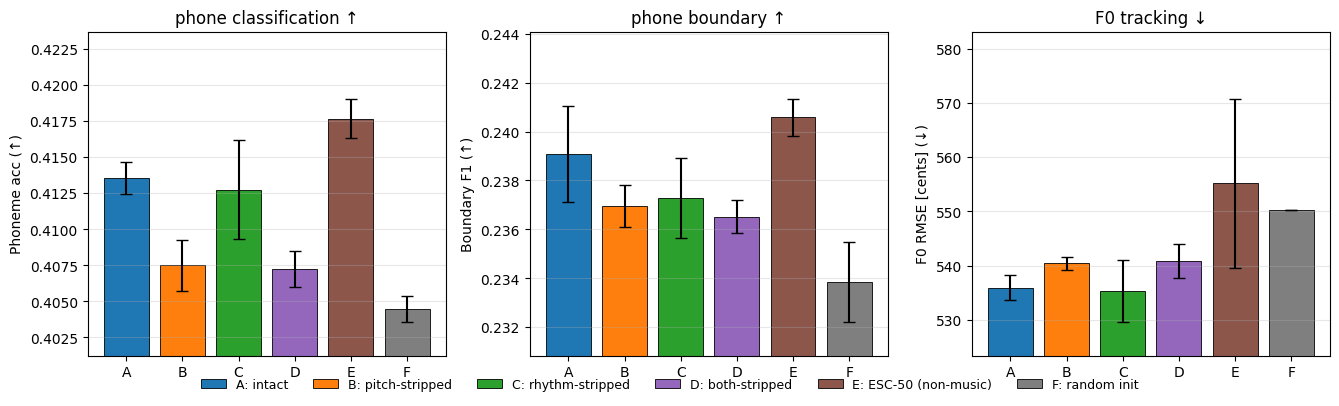

In [7]:
from matplotlib.patches import Patch

COND_COLOR = {
    "intact":       "#1f77b4",
    "pitch_strip":  "#ff7f0e",
    "rhythm_strip": "#2ca02c",
    "both_strip":   "#9467bd",
    "esc50":        "#8c564b",
    "random_init":  "#7f7f7f",
}

# Arrow follows the metric direction; ↑ = higher is better, ↓ = lower is better.
ARROW = {"high": "↑", "low": "↓"}
TASK_TITLE = {
    "phone":    f"phone classification {ARROW['high']}",
    "boundary": f"phone boundary {ARROW['high']}",
    "f0":       f"F0 tracking {ARROW['low']}",
    "ks":       f"keyword spotting {ARROW['high']}",
    "sid":      f"speaker ID {ARROW['high']}",
}

fig, axes = plt.subplots(1, len(TASKS), figsize=(3.5 * len(TASKS), 4.0))
if len(TASKS) == 1:
    axes = [axes]

for ax, (task, info) in zip(axes, TASKS.items()):
    sub = df[df["task"] == task]
    means_s = sub.groupby("cond")["value"].mean().reindex(CONDS)
    stds_s  = sub.groupby("cond")["value"].std().reindex(CONDS).fillna(0.0)

    valid = means_s.notna()
    xs = np.arange(len(CONDS))
    ax.bar(
        xs[valid],
        means_s[valid].values,
        yerr=stds_s[valid].values,
        capsize=4,
        color=[COND_COLOR[c] for c in np.array(CONDS)[valid]],
        edgecolor="black",
        linewidth=0.6,
    )

    ax.set_xticks(xs)
    ax.set_xticklabels([COND_LABEL[c].split(":", 1)[0] for c in CONDS], rotation=0)
    ax.set_ylabel(info["label"])
    ax.set_title(TASK_TITLE[task])
    ax.grid(axis="y", alpha=0.3)

    if valid.any():
        lo = (means_s[valid] - stds_s[valid]).min()
        hi = (means_s[valid] + stds_s[valid]).max()
        pad = (hi - lo) * 0.15
        ax.set_ylim(lo - pad, hi + pad * 2)

# Figure-level legend showing color -> condition mapping.
legend_handles = [
    Patch(facecolor=COND_COLOR[c], edgecolor="black", linewidth=0.6, label=COND_LABEL[c])
    for c in CONDS
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(CONDS),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIG_DIR / "probe_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Legend (condition codes):

- **A** intact: original POP909 audio
- **B** pitch-stripped: per-track fixed pitches, rhythm preserved
- **C** rhythm-stripped: per-track pitches preserved, every onset floored to its containing beat
- **D** both-stripped: pitch + rhythm both ablated
- **E** ESC-50: environmental audio (non-music control)
- **F** random init: no pretrain (lower-bound baseline)